# Sistema híbrido de recomendación de anime

**Trabajo Práctico 2 — Análisis Predictivo Avanzado**

Este notebook construye, optimiza y evalúa un sistema de recomendación top-k para una plataforma hipotética de streaming de anime.

El objetivo operativo consiste en seleccionar los diez títulos no vistos que deberían mostrarse primero a cada usuario. La implementación compara baselines de popularidad y contenido con modelos colaborativos e híbridos entrenados mediante objetivos logísticos, BPR y muestreo de negativos difíciles inspirado en WARP.

## 1. Diseño del experimento

La unidad de análisis es una interacción positiva entre un usuario y un anime. Se considera positiva una calificación explícita de al menos 8 puntos.

El conjunto de datos no contiene marcas temporales confiables. Por este motivo, la separación se realiza aleatoriamente dentro de cada usuario, utilizando semillas determinísticas. Cada usuario conserva observaciones en entrenamiento, validación y prueba.

La validación se utilizará para comparar arquitecturas, pérdidas e hiperparámetros. El conjunto de prueba permanecerá reservado hasta que todas las decisiones de modelado hayan sido fijadas.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from anime_recommender import (
    load_experiment_config,
    prepare_data,
)

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CONFIG_PATH = ROOT / "config" / "experiment.json"
ANIME_PATH = ROOT / "data" / "anime.csv"
RATINGS_PATH = ROOT / "data" / "rating.parquet"

config = load_experiment_config(CONFIG_PATH)

print("Project root:", ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Modeling framework:", config["framework"])
print("Device:", config["device"])

Project root: C:\TP2\AnimeLightFM
Python: 3.11.15
Platform: Windows-10-10.0.26200-SP0
Modeling framework: pytorch
Device: cpu


In [2]:
display(
    pd.DataFrame(
        {
            "Parameter": list(config.keys()),
            "Value": [
                json.dumps(value)
                if isinstance(value, (list, dict))
                else value
                for value in config.values()
            ],
        }
    )
)

,Parameter,Value
0,experiment_name,anime_hybrid_pytorch
1,framework,pytorch
2,seed,42
3,positive_rating_threshold,8
4,target_user_count,1500
5,minimum_user_positives_before_sampling,20
6,maximum_user_positives_before_sampling,300
7,minimum_user_positives_after_filtering,15
8,minimum_item_users,5
9,validation_fraction,0.1


## 2. Carga, validación y definición de interacciones positivas

El catálogo y las calificaciones se validan antes de cualquier modelado. Los identificadores se convierten a enteros, los títulos se normalizan y las referencias a anime inexistentes se eliminan.

Las calificaciones iguales a `-1` representan consumo sin una evaluación explícita. Se excluyen del conjunto positivo principal. Una interacción positiva requiere una calificación mayor o igual a 8.

In [3]:
prepared = prepare_data(
    anime_path=ANIME_PATH,
    ratings_path=RATINGS_PATH,
    config=config,
)

summary_table = pd.DataFrame(
    {
        "Measure": list(prepared.summary.keys()),
        "Value": list(prepared.summary.values()),
    }
)

display(summary_table)

,Measure,Value
0,anime_sha256,26c27b66120342544f19c9acb575e3dcbf37d46d1898ae...
1,ratings_sha256,5f70fd74327974c0c2c35159efba1a0a5634de139e09ff...
2,raw_catalog_rows,12294
3,raw_rating_rows,7813737
4,rows_with_missing_required_values,0
5,rows_participating_in_duplicate_pairs,14
6,duplicate_pair_records_removed,7
7,deduplicated_rating_rows,7813730
8,orphan_rating_rows_removed,10
9,positive_interactions_before_sampling,3855825


## 3. Cohorte determinística

Los usuarios candidatos deben tener suficiente historial positivo para sostener una evaluación individual. Los identificadores elegibles se ordenan antes del muestreo y se utiliza una semilla fija.

Luego se aplican iterativamente dos restricciones:

- Cada usuario debe conservar como mínimo la cantidad configurada de interacciones positivas.
- Cada anime debe haber sido valorado positivamente por al menos la cantidad configurada de usuarios.

El proceso se repite hasta que ambas condiciones se cumplen simultáneamente.

In [4]:
user_positive_counts = (
    prepared.interactions
    .groupby("user_id")
    .size()
)

item_positive_counts = (
    prepared.interactions
    .groupby("anime_id")
    .size()
)

count_diagnostics = pd.DataFrame(
    {
        "Statistic": [
            "Users",
            "Items",
            "Positive interactions",
            "Minimum positives per user",
            "Median positives per user",
            "Maximum positives per user",
            "Minimum users per item",
            "Median users per item",
            "Maximum users per item",
        ],
        "Value": [
            prepared.interactions["user_id"].nunique(),
            prepared.interactions["anime_id"].nunique(),
            len(prepared.interactions),
            user_positive_counts.min(),
            user_positive_counts.median(),
            user_positive_counts.max(),
            item_positive_counts.min(),
            item_positive_counts.median(),
            item_positive_counts.max(),
        ],
    }
)

display(count_diagnostics)

,Statistic,Value
0,Users,1498.0
1,Items,2438.0
2,Positive interactions,110025.0
3,Minimum positives per user,17.0
4,Median positives per user,54.0
5,Maximum positives per user,292.0
6,Minimum users per item,5.0
7,Median users per item,19.0
8,Maximum users per item,805.0


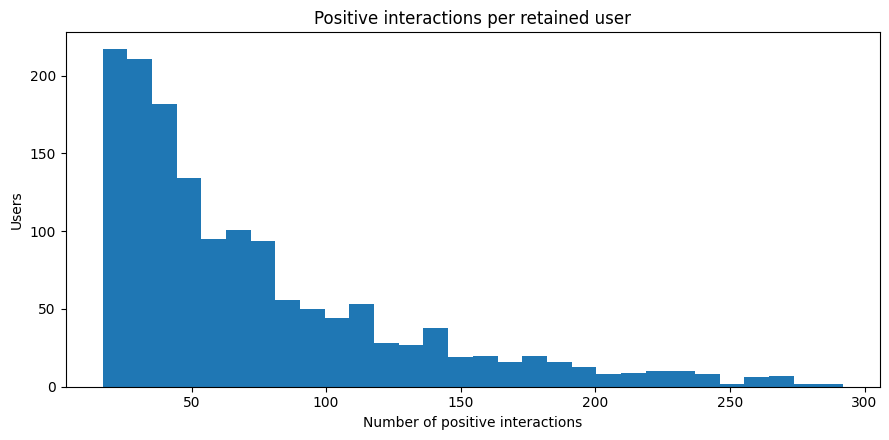

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    user_positive_counts,
    bins=30,
)

ax.set_title(
    "Positive interactions per retained user"
)
ax.set_xlabel(
    "Number of positive interactions"
)
ax.set_ylabel(
    "Users"
)

plt.tight_layout()
plt.show()

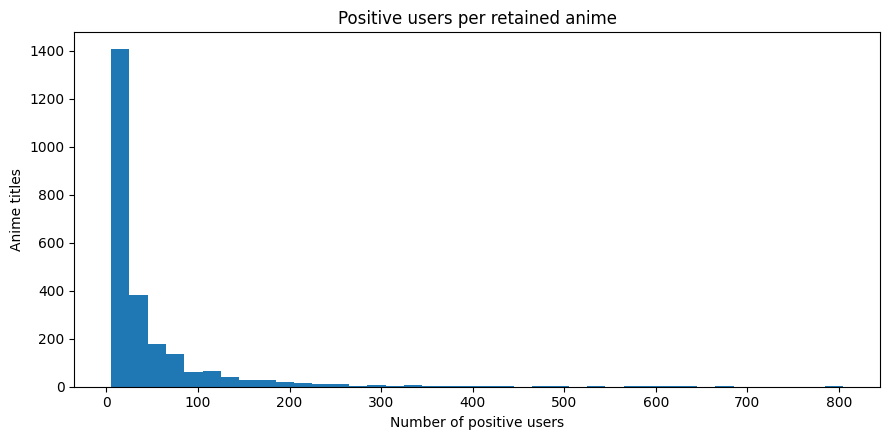

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    item_positive_counts,
    bins=40,
)

ax.set_title(
    "Positive users per retained anime"
)
ax.set_xlabel(
    "Number of positive users"
)
ax.set_ylabel(
    "Anime titles"
)

plt.tight_layout()
plt.show()

## 4. Train, validation and test split

Every user has at least one validation interaction and one test interaction. The remainder is assigned to training.

A deterministic repair step guarantees that every retained anime appears at least once in training. When necessary, it exchanges a held-out interaction with a training interaction from the same user without leaving the replacement anime unsupported.

This avoids evaluating collaborative models on item identifiers that were never observed during training.

In [7]:
split_counts = (
    prepared.split_interactions
    .groupby("split")
    .agg(
        interactions=("anime_id", "size"),
        users=("user_id", "nunique"),
        items=("anime_id", "nunique"),
    )
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

display(split_counts)

,interactions,users,items
split,,,
train,89313,1498,2438
validation,10356,1498,1878
test,10356,1498,1875


In [8]:
per_user_split_counts = (
    prepared.split_interactions
    .groupby(
        [
            "user_id",
            "split",
        ]
    )
    .size()
    .unstack(fill_value=0)
)

display(
    per_user_split_counts.describe().T
)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,1498.0,6.913218,5.475074,1.0,3.0,5.0,9.0,29.0
train,1498.0,59.621495,43.864981,15.0,27.0,44.0,78.0,234.0
validation,1498.0,6.913218,5.475074,1.0,3.0,5.0,9.0,29.0


In [9]:
assert (
    prepared.train_matrix.multiply(
        prepared.validation_matrix
    ).nnz
    == 0
)

assert (
    prepared.train_matrix.multiply(
        prepared.test_matrix
    ).nnz
    == 0
)

assert (
    prepared.validation_matrix.multiply(
        prepared.test_matrix
    ).nnz
    == 0
)

assert prepared.summary[
    "items_without_training_support"
] == 0

assert (
    prepared.train_matrix.nnz
    + prepared.validation_matrix.nnz
    + prepared.test_matrix.nnz
    == prepared.all_positive_matrix.nnz
)

print(
    "Split integrity checks passed."
)
print(
    "Cohort hash:",
    prepared.summary[
        "cohort_split_sha256"
    ],
)

Split integrity checks passed.
Cohort hash: 02a81cb1bbdf5e955469426444a2500443a4412217197821e4f66d3c71dec1bf


## 5. Phase 2 conclusion

The final cohort, mappings, and split assignments are deterministic and free of overlap. Every retained user is represented in all three subsets, and every retained item has training support.

The following sections will construct metadata features, evaluation functions, baselines, and the collaborative and hybrid recommendation models.